# Telco Customer Churn - Exploratory Data Analysis

This notebook performs comprehensive EDA on the Telco Customer Churn dataset to understand factors influencing customer churn.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Load and Explore Dataset

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print(f"\nTotal Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: (7043, 21)

Total Records: 7043
Total Features: 21


In [3]:
# First few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Column names and data types
column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})
column_info

,Column,Data Type,Non-Null Count,Null Count,Unique Values
0,customerID,object,7043,0,7043
1,gender,object,7043,0,2
2,SeniorCitizen,int64,7043,0,2
3,Partner,object,7043,0,2
4,Dependents,object,7043,0,2
5,tenure,int64,7043,0,73
6,PhoneService,object,7043,0,2
7,MultipleLines,object,7043,0,3
8,InternetService,object,7043,0,3
9,OnlineSecurity,object,7043,0,3


## 3. Data Cleaning & Preprocessing

In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# TotalCharges should be numeric - convert and handle errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges: 11


In [8]:
# Inspect rows with missing TotalCharges
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
# These are new customers with tenure=0, fill with 0 or drop
# Option 1: Fill with 0
df['TotalCharges'].fillna(0, inplace=True)

# Option 2: Drop rows (uncomment if preferred)
# df.dropna(subset=['TotalCharges'], inplace=True)

print(f"Missing values after handling: {df['TotalCharges'].isnull().sum()}")

Missing values after handling: 0


In [10]:
# Convert SeniorCitizen to categorical for better analysis
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

## 4. Descriptive Statistics

In [11]:
# Numerical columns statistics
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [12]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns: {categorical_cols}")

Categorical Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## 5. Target Variable Analysis - Churn Distribution

In [13]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {churn_percentage['Yes']:.2f}%")

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


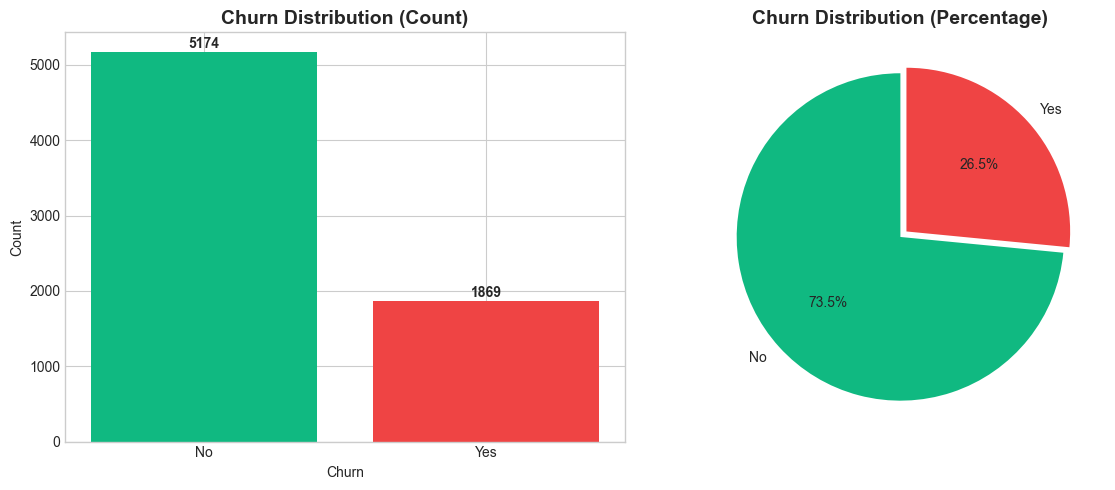

In [14]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#10b981', '#ef4444']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Numerical Features Analysis

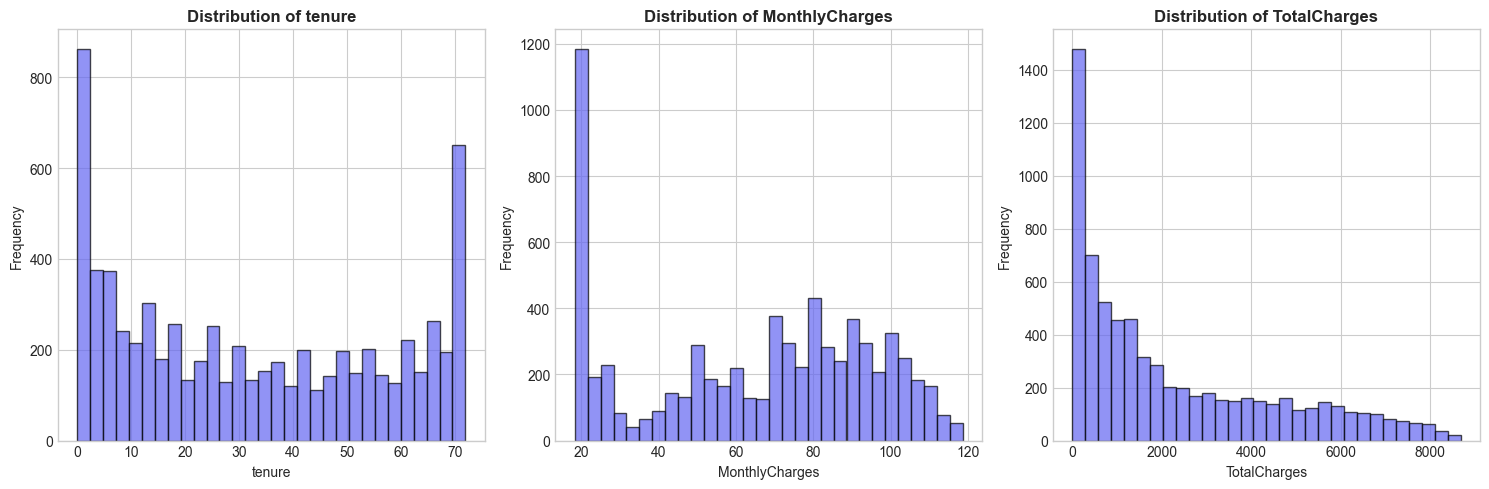

In [15]:
# Distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='#6366f1')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

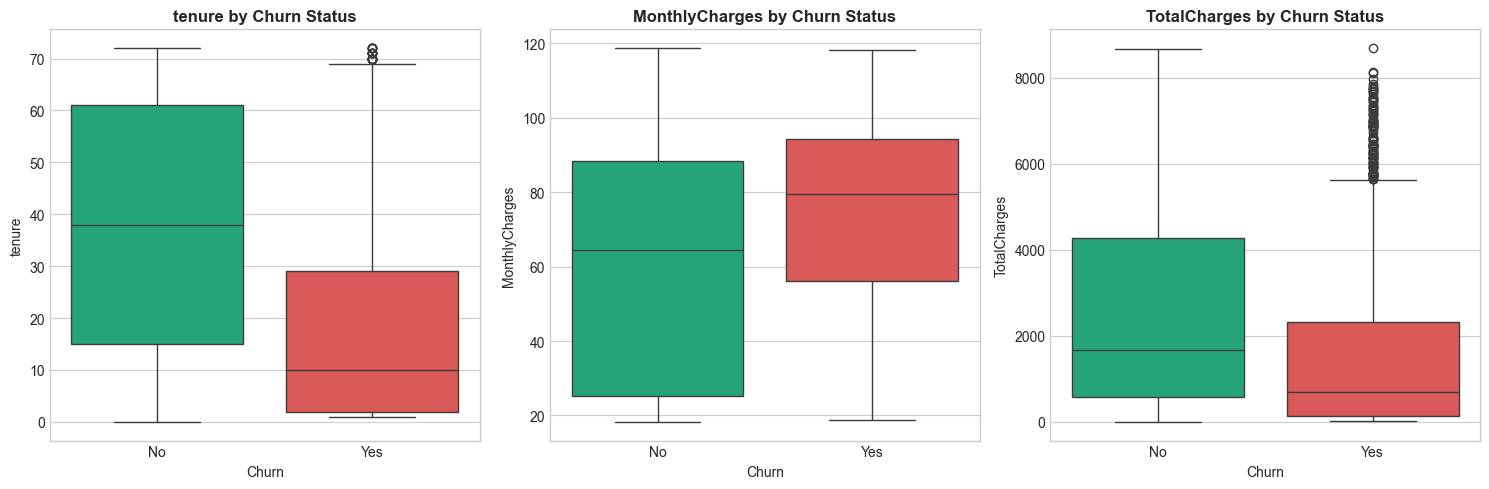

In [16]:
# Box plots by Churn status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette=['#10b981', '#ef4444'])
    axes[i].set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.1 Tenure Analysis

In [17]:
# Create tenure groups
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

# Churn rate by tenure group
tenure_churn = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack() * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


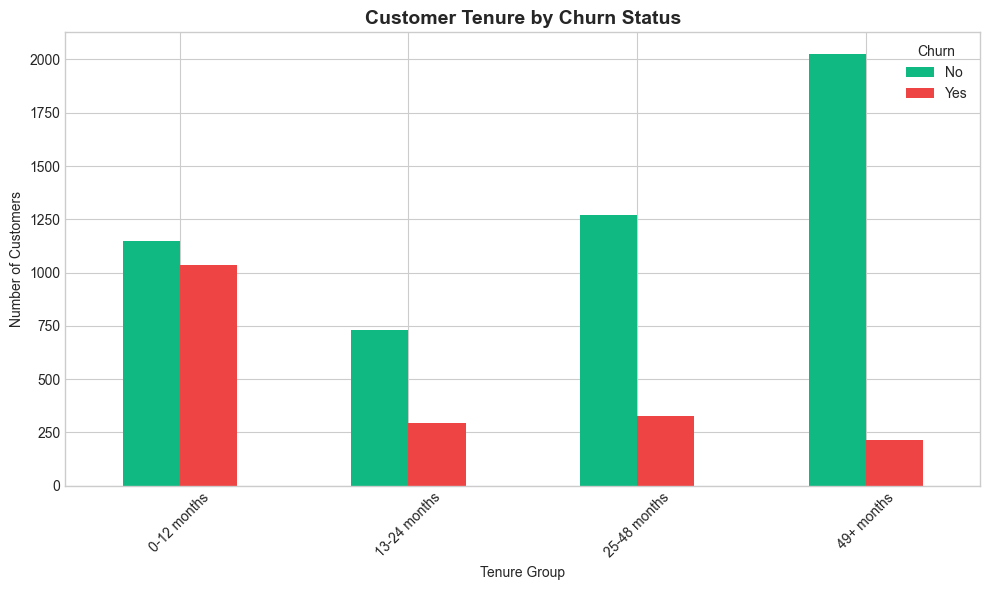

In [18]:
# Visualize tenure vs churn
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
tenure_counts = df.groupby(['TenureGroup', 'Churn']).size().unstack(fill_value=0)
tenure_counts = tenure_counts.reindex(tenure_order)

fig, ax = plt.subplots(figsize=(10, 6))
tenure_counts.plot(kind='bar', ax=ax, color=['#10b981', '#ef4444'])
ax.set_title('Customer Tenure by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Monthly Charges Analysis

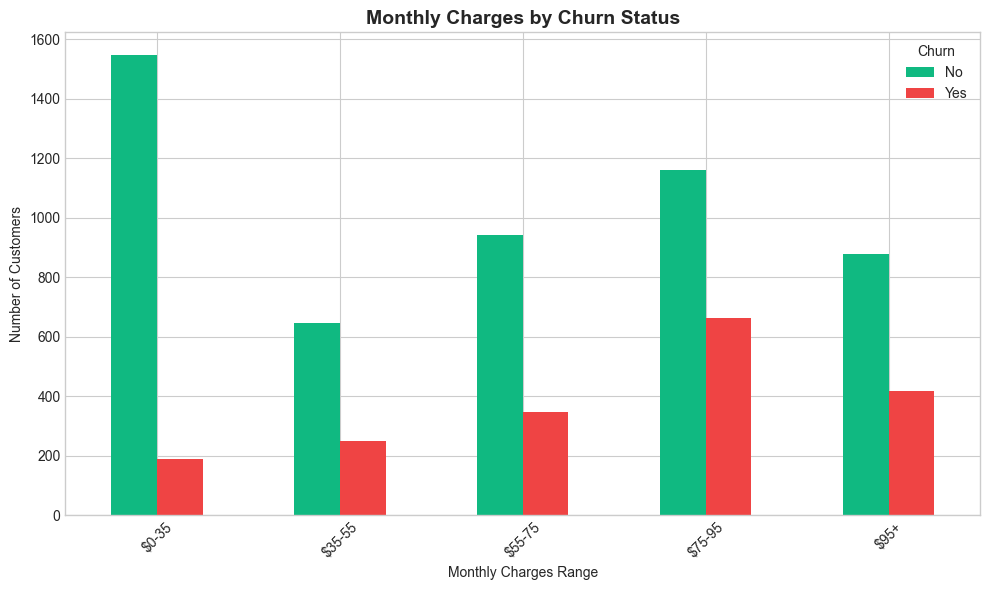

In [19]:
# Create monthly charges groups
def charges_group(charges):
    if charges <= 35:
        return '$0-35'
    elif charges <= 55:
        return '$35-55'
    elif charges <= 75:
        return '$55-75'
    elif charges <= 95:
        return '$75-95'
    else:
        return '$95+'

df['ChargesGroup'] = df['MonthlyCharges'].apply(charges_group)

# Churn by charges group
charges_order = ['$0-35', '$35-55', '$55-75', '$75-95', '$95+']
charges_counts = df.groupby(['ChargesGroup', 'Churn']).size().unstack(fill_value=0)
charges_counts = charges_counts.reindex(charges_order)

fig, ax = plt.subplots(figsize=(10, 6))
charges_counts.plot(kind='bar', ax=ax, color=['#10b981', '#ef4444'])
ax.set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges Range')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Categorical Features Analysis

In [20]:
# Key categorical features to analyze
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

In [21]:
# Churn rate by categorical features
def churn_rate_by_feature(feature):
    return df.groupby(feature)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)

for feature in cat_features:
    print(f"\n{feature}:")
    print(churn_rate_by_feature(feature).round(2))


gender:
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

SeniorCitizen:
SeniorCitizen
No     23.61
Yes    41.68
Name: Churn, dtype: float64

Partner:
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents:
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

PhoneService:
PhoneService
No     24.93
Yes    26.71
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
No                  25.04
No phone service    24.93
Yes                 28.61
Name: Churn, dtype: float64

InternetService:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

OnlineBackup:
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Churn, dtype: float64

DeviceProtection:
DeviceProtection
No                   

### 7.1 Contract Type Analysis

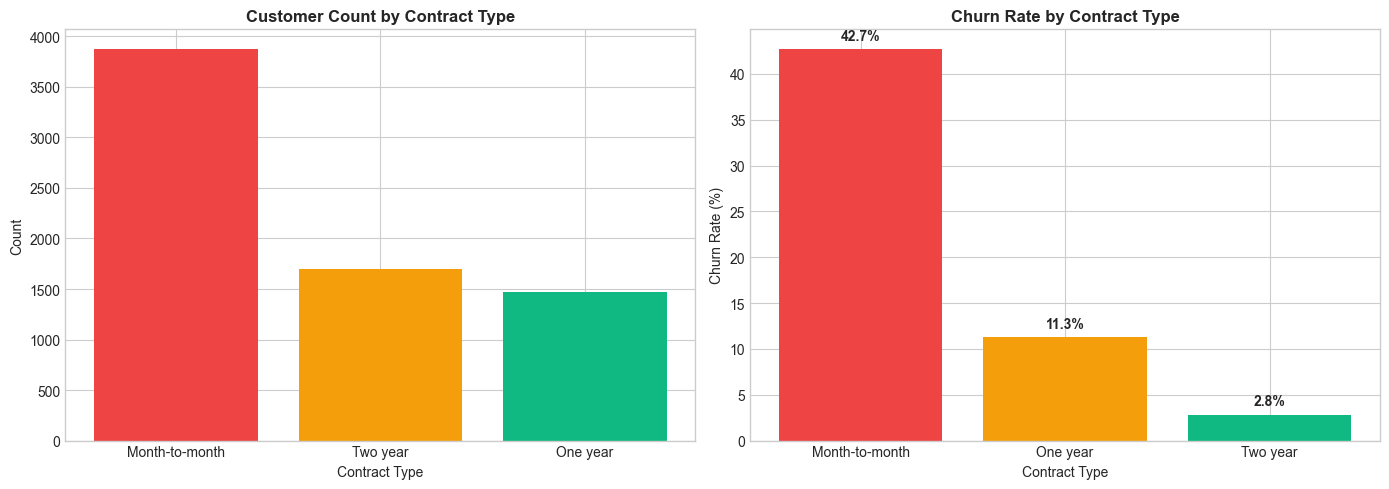

In [22]:
# Contract type distribution and churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by contract type
contract_counts = df['Contract'].value_counts()
axes[0].bar(contract_counts.index, contract_counts.values, color=['#ef4444', '#f59e0b', '#10b981'])
axes[0].set_title('Customer Count by Contract Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')

# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
axes[1].bar(contract_churn.index, contract_churn.values, color=['#ef4444', '#f59e0b', '#10b981'])
axes[1].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2 Payment Method Analysis

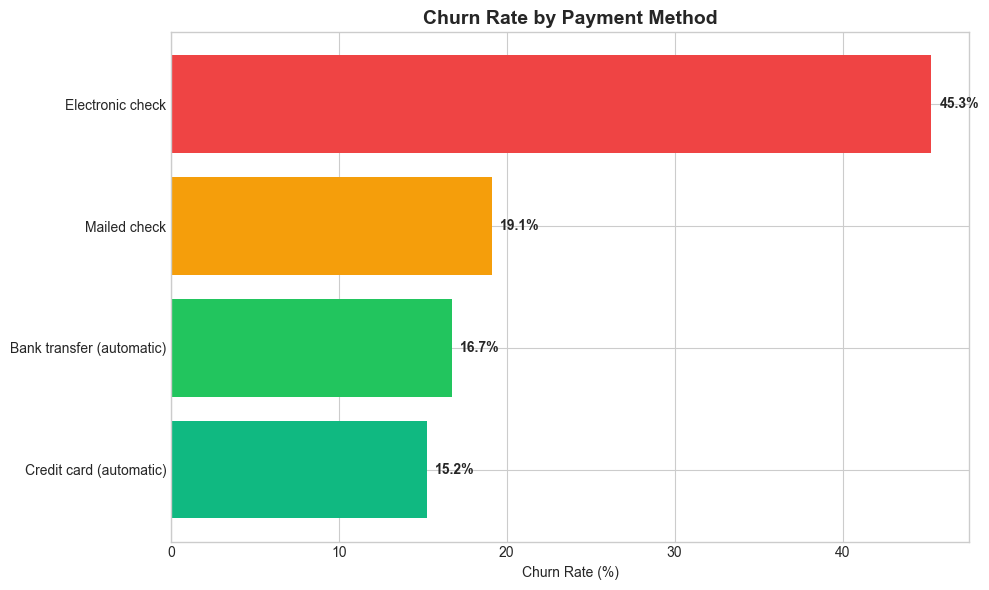

In [23]:
# Payment method and churn
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#10b981', '#22c55e', '#f59e0b', '#ef4444']
ax.barh(payment_churn.index, payment_churn.values, color=colors)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for i, v in enumerate(payment_churn.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.3 Internet Service Analysis

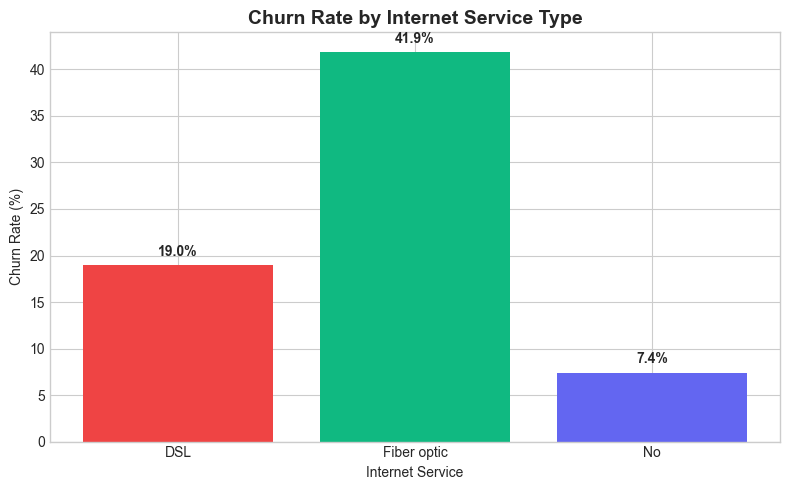

In [24]:
# Internet service and churn
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(internet_churn.index, internet_churn.values, color=['#ef4444', '#10b981', '#6366f1'])
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

In [25]:
# Create binary encoding for correlation
df_encoded = df.copy()

# Binary encode Churn
df_encoded['Churn_Binary'] = (df_encoded['Churn'] == 'Yes').astype(int)

# Encode other binary features
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col == 'gender':
        df_encoded[col] = (df_encoded[col] == 'Male').astype(int)
    else:
        df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# SeniorCitizen
df_encoded['SeniorCitizen'] = (df_encoded['SeniorCitizen'] == 'Yes').astype(int)

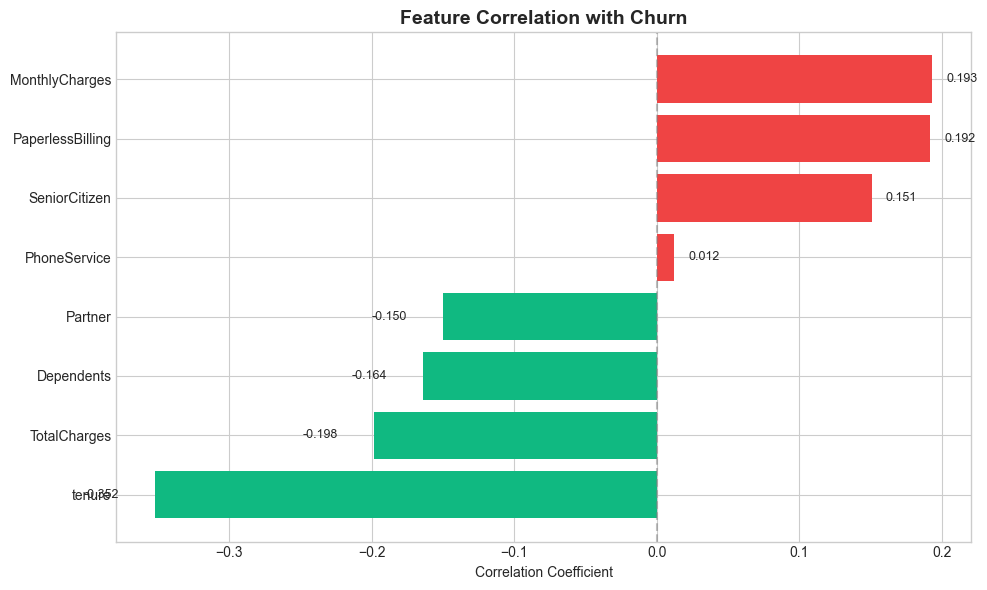

In [26]:
# Correlation with Churn
correlation_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 
                        'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

correlations = df_encoded[correlation_features + ['Churn_Binary']].corr()['Churn_Binary'].drop('Churn_Binary').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#10b981' if x < 0 else '#ef4444' for x in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.set_title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(correlations.values):
    ax.text(v + 0.01 if v > 0 else v - 0.05, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

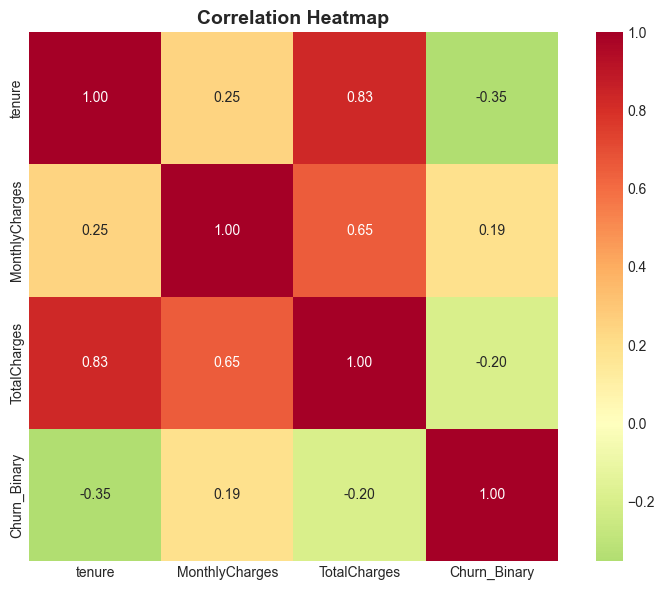

In [27]:
# Correlation heatmap for numerical features
numerical_df = df_encoded[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='RdYlGn_r', center=0, 
            fmt='.2f', square=True, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Key Insights Summary

In [28]:
insights = [
    {
        'Finding': 'High Churn Rate',
        'Detail': f"Overall churn rate is {churn_percentage['Yes']:.1f}% ({churn_counts['Yes']} customers)",
        'Type': 'Warning'
    },
    {
        'Finding': 'Month-to-Month Risk',
        'Detail': 'Month-to-month contracts have ~42% churn rate vs ~3% for 2-year contracts',
        'Type': 'Warning'
    },
    {
        'Finding': 'Tenure Impact',
        'Detail': 'New customers (0-12 months) churn most - focus on early retention',
        'Type': 'Insight'
    },
    {
        'Finding': 'Payment Method Risk',
        'Detail': 'Electronic check users have highest churn rate (~45%)',
        'Type': 'Warning'
    },
    {
        'Finding': 'Fiber Optic Concern',
        'Detail': 'Fiber optic customers churn more (~42%) than DSL customers (~19%)',
        'Type': 'Insight'
    },
    {
        'Finding': 'Support Services Help',
        'Detail': 'Tech support and online security reduce churn significantly',
        'Type': 'Recommendation'
    }
]

insights_df = pd.DataFrame(insights)
insights_df

,Finding,Detail,Type
0,High Churn Rate,Overall churn rate is 26.5% (1869 customers),Warning
1,Month-to-Month Risk,Month-to-month contracts have ~42% churn rate ...,Warning
2,Tenure Impact,New customers (0-12 months) churn most - focus...,Insight
3,Payment Method Risk,Electronic check users have highest churn rate...,Warning
4,Fiber Optic Concern,Fiber optic customers churn more (~42%) than D...,Insight
5,Support Services Help,Tech support and online security reduce churn ...,Recommendation


## 10. Conclusion & Recommendations

In [29]:
print("""
=== TELCO CUSTOMER CHURN EDA - CONCLUSIONS ===

KEY FINDINGS:
1. The overall churn rate is approximately 26.5% (1,869 out of 7,043 customers)

2. STRONGEST CHURN PREDICTORS (Negative factors):
   - Month-to-month contracts (~42% churn rate)
   - Electronic check payment method (~45% churn rate)
   - Fiber optic internet service (~42% churn rate)
   - Low tenure (new customers < 12 months)
   - Higher monthly charges

3. RETENTION FACTORS (Positive factors):
   - Long-term contracts (1-year: ~11%, 2-year: ~3% churn rate)
   - Longer tenure (49+ months: ~7% churn rate)
   - Tech support subscription
   - Online security subscription
   - Partners and dependents

RECOMMENDATIONS:
1. Implement early intervention programs for new customers (first 12 months)
2. Incentivize month-to-month customers to switch to longer contracts
3. Investigate fiber optic service quality issues
4. Encourage automatic payment methods over electronic checks
5. Bundle tech support and security services to increase retention
6. Create loyalty programs for long-term customers
""")


=== TELCO CUSTOMER CHURN EDA - CONCLUSIONS ===

KEY FINDINGS:
1. The overall churn rate is approximately 26.5% (1,869 out of 7,043 customers)

2. STRONGEST CHURN PREDICTORS (Negative factors):
   - Month-to-month contracts (~42% churn rate)
   - Electronic check payment method (~45% churn rate)
   - Fiber optic internet service (~42% churn rate)
   - Low tenure (new customers < 12 months)
   - Higher monthly charges

3. RETENTION FACTORS (Positive factors):
   - Long-term contracts (1-year: ~11%, 2-year: ~3% churn rate)
   - Longer tenure (49+ months: ~7% churn rate)
   - Tech support subscription
   - Online security subscription
   - Partners and dependents

RECOMMENDATIONS:
1. Implement early intervention programs for new customers (first 12 months)
2. Incentivize month-to-month customers to switch to longer contracts
3. Investigate fiber optic service quality issues
4. Encourage automatic payment methods over electronic checks
5. Bundle tech support and security services to increa

In [30]:
# Save cleaned dataset
df.to_csv('telco_churn_cleaned.csv', index=False)
print("Cleaned dataset saved to 'telco_churn_cleaned.csv'")

Cleaned dataset saved to 'telco_churn_cleaned.csv'
